# Final Project

## Read Cleveland Heart Disease Dataset

In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import pandas as pd
import numpy as np
from time import time

In [52]:

file_path = "/content/drive/MyDrive/SYDE522Final/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
df = pd.read_csv(file_path, delimiter=",", names=column_names, header=None)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [54]:
# display dataframe
# with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#     display(df)

In [55]:
# Count the number of times '0' appears in the 'num' column of the DataFrame.
zero_count = df['num'].value_counts().get(0, 0)
print(f"The number 0 appears {zero_count} times in the 'num' column.")

The number 0 appears 164 times in the 'num' column.


## Preprocessing

### Replace missing values

In [56]:
# Find rows with "?" in any column
rows_with_question_marks = df[df.apply(lambda row: row.astype(str).str.contains('\?').any(), axis=1)]

# Display the rows with "?"
rows_with_question_marks

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0


In [57]:
# replace ? with mode
df_copy = df.copy()

for col in df.columns:
    if df_copy[col].dtype == 'object':  # Check if the column is of object type (likely contains strings)
        mode_val = df_copy[col].dropna().astype(str).mode()[0]  # Use mode for string columns
        df_copy[col] = df[col].replace('?', mode_val)

    elif pd.api.types.is_numeric_dtype(df_copy[col]):  # Check if the column is numeric
        mode_val = df_copy[col].astype('float64').mode()[0]
        df_copy[col] = df_copy[col].replace('?', mode_val)

### Change "object" datatype to "float64"

In [58]:
# prompt: for df_copy, change column "ca", "thal" datatype to float64

df_copy['ca'] = df_copy['ca'].astype('float64')
df_copy['thal'] = df_copy['thal'].astype('float64')

### Change labels and plot its distribution

In [59]:
# we want to predict the presence of heart disease (binary classification)
# change labels 2,3,4 to 1
df_copy['num'] = df_copy['num'].replace([2, 3, 4], 1)

In [60]:
# Split data into features and target
Features = df_copy.drop('num', axis=1)
Labels = df_copy['num']

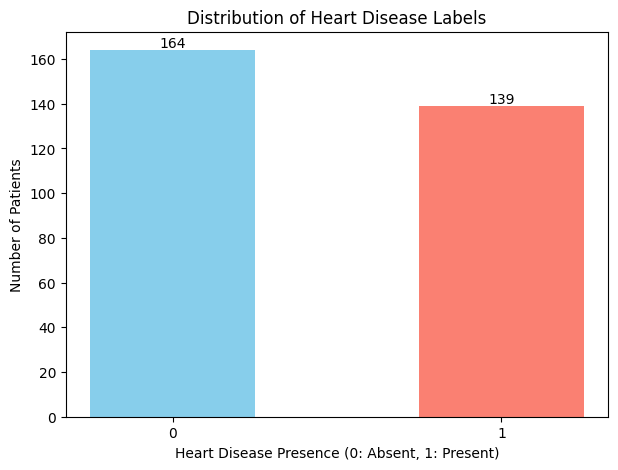

In [61]:
import matplotlib.pyplot as plt

# Count the occurrences of each label
label_counts = Labels.value_counts()

plt.figure(figsize=(7, 5))
bars = plt.bar(label_counts.index, label_counts.values, width=0.5, color=['skyblue', 'salmon'])  # Different colors for 0 and 1

plt.xlabel('Heart Disease Presence (0: Absent, 1: Present)')
plt.xticks([0, 1])
plt.ylabel('Number of Patients')
plt.title('Distribution of Heart Disease Labels')

for bar, count in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count), ha='center', va='bottom')

plt.show()

### Train Test Split

In [62]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(Features, Labels, test_size=0.25, random_state=42) # 80% train
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (227, 13)
y_train shape: (227,)
X_test shape: (76, 13)
y_test shape: (76,)


### Normalization

In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Fit the scaler to the training data
scaler.fit(X_train)

# Transform both the training and testing data using the fitted scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Correlation Matrix

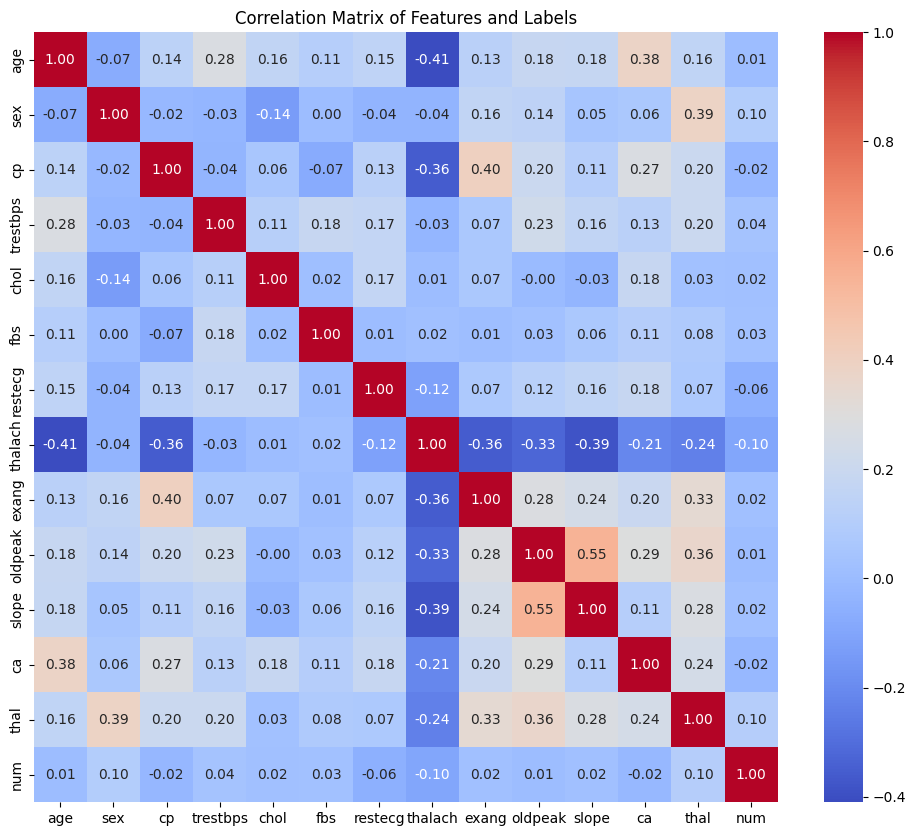

In [64]:
import seaborn as sns

# Combine features and labels for correlation analysis
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=['age', 'sex', 'cp', 'trestbps',
         'chol', 'fbs', 'restecg','thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'])
train_data = pd.concat([X_train_scaled_df, y_train], axis=1)

# Calculate the correlation matrix
correlation_matrix = train_data.corr()

# Plotting the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Labels')
plt.show()

### PCA

In [65]:
from sklearn.decomposition import PCA

# Initialize PCA with the desired explained variance ratio
pca = PCA(n_components=0.80)  # Keep 80% of the variance

# Fit PCA on the scaled training data
pca.fit(X_train_scaled)

# Transform the training and testing data using the fitted PCA
X_train_scaled_pca = pca.transform(X_train_scaled)
X_test_scaled_pca = pca.transform(X_test_scaled)

print("Number of components kept:", pca.n_components_)
print("X_train_pca shape:", X_train_scaled_pca.shape)
print("X_test_pca shape:", X_test_scaled_pca.shape)

Number of components kept: 6
X_train_pca shape: (227, 6)
X_test_pca shape: (76, 6)


## Logistic Regression

In [66]:
# Import libraries for training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, KFold



In [67]:
# Pick 5% of the training set
train_size = int(0.05 * len(X_train_scaled_pca))
X_train_small = X_train_scaled_pca[:train_size]
y_train_small = y_train[:train_size]

# Set regularization to zero and train Logistic Regression
logreg = LogisticRegression(penalty='l2', C=1e9, solver='lbfgs', max_iter=500) # C=1e9 effectively sets regularization to zero
logreg.fit(X_train_small, y_train_small)

# Make predictions on the small training set
y_pred = logreg.predict(X_train_small)

# Calculate Mean Squared Error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_train_small, y_pred)
print(f"Mean Squared Error on the small training set: {mse}")

Mean Squared Error on the small training set: 0.0


In [68]:
# Logistic Regression
# Apply Grid search and K-fold cross validation to tune hyperparameters

from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Logistic Regression
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], # Regularization strength
}

# Initialize Logistic Regression
logreg = LogisticRegression(penalty='l2', max_iter=500)

# Perform GridSearchCV
grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy')  # 5-fold cross-validation
start = time()
grid_search.fit(X_train_scaled_pca, y_train)
end = time()
print("search time: ", end - start)
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search.best_params_)
print("Validation accuracy:", grid_search.best_score_)


search time:  0.16901659965515137
Best hyperparameters: {'C': 1}
Validation accuracy: 0.8193236714975844


In [69]:
from sklearn.metrics import accuracy_score

# use the best hyperparameter to train on whole train set
tuned_logreg = LogisticRegression(penalty='l2', C=1, solver='lbfgs', max_iter=500)
tuned_logreg.fit(X_train_scaled_pca, y_train)

y_train_pred = tuned_logreg.predict(X_train_scaled_pca)
y_pred_lr = tuned_logreg.predict(X_test_scaled_pca)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_lr)}")


Training Accuracy: 0.8193832599118943
Testing Accuracy: 0.8289473684210527


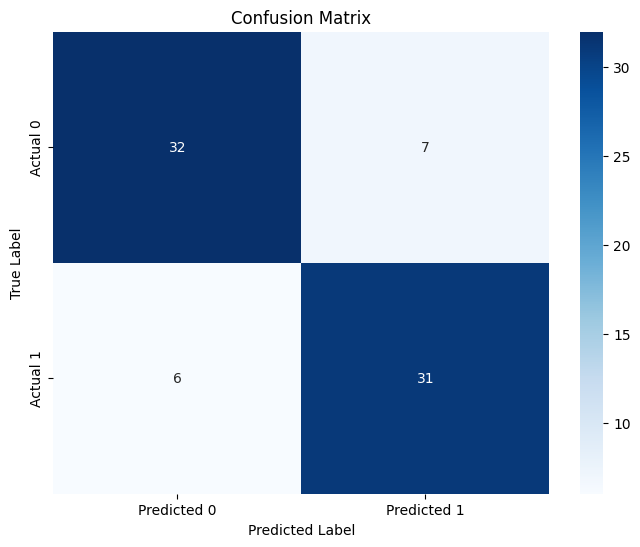

In [70]:
# Plot confusion matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## SVM

In [71]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import mean_squared_error

# Pick 5% of the training set
train_size = int(0.05 * len(X_train_scaled_pca))
X_train_small = X_train_scaled_pca[:train_size]
y_train_small = y_train[:train_size]

# Set regularization to zero
svm = SGDClassifier(loss='hinge', penalty=None, max_iter=500, random_state=42) # penalty=None sets regularization to zero
svm.fit(X_train_small, y_train_small)

# Make predictions
y_pred = svm.predict(X_train_small)

# Calculate Mean Squared Error
mse = mean_squared_error(y_train_small, y_pred)
print(f"Mean Squared Error on the small training set: {mse}")

Mean Squared Error on the small training set: 0.0


### SVM with PCA

In [72]:
from sklearn.linear_model import SGDClassifier
# Define the parameter grid for SVM
param_grid2 = {# 'penalty': ['l1', 'l2'],
              'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
              'eta0': [0.0001, 0.001, 0.01, 0.1, 1, 10],
              'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive']
              }

# Initialize SGDClassifier
svm = SGDClassifier(loss='hinge', penalty='l2', max_iter=500, random_state=42)

# Perform GridSearchCV
grid_search2 = GridSearchCV(svm, param_grid2, cv=5, scoring='accuracy')  # 5-fold cross-validation
start = time()
grid_search2.fit(X_train_scaled_pca, y_train)
end = time()
print("search time: ", end - start)

# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search2.best_params_)
print("Validation accuracy:", grid_search2.best_score_)


search time:  3.4172537326812744
Best hyperparameters: {'alpha': 0.1, 'eta0': 0.1, 'learning_rate': 'constant'}
Validation accuracy: 0.8324637681159419


In [73]:
# use the best hyperparameter to train on whole train set
tuned_svm = SGDClassifier(loss='hinge', penalty='l2', alpha=0.1, eta0=0.1, learning_rate='constant', max_iter=500, random_state=42)
tuned_svm.fit(X_train_scaled_pca, y_train)

y_train_pred = tuned_svm.predict(X_train_scaled_pca)
y_pred_svm = tuned_svm.predict(X_test_scaled_pca)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_svm)}")

Training Accuracy: 0.8061674008810573
Testing Accuracy: 0.8552631578947368


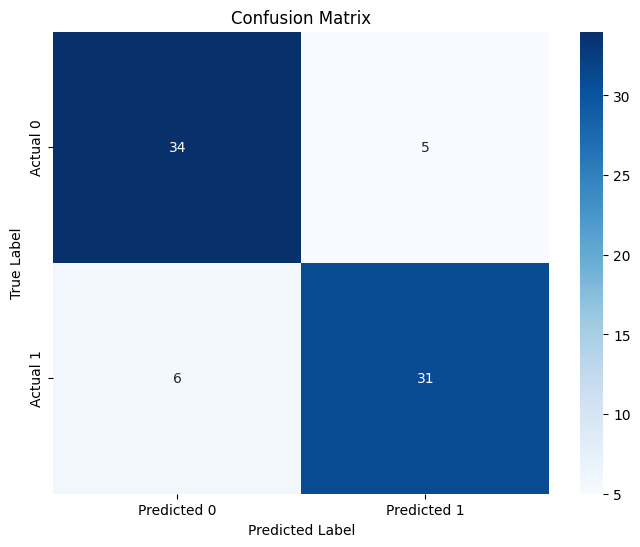

In [74]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### SVM without PCA

In [75]:
from sklearn.linear_model import SGDClassifier
# Define the parameter grid for SVM
param_grid2 = {# 'penalty': ['l1', 'l2'],
              'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
              'eta0': [0.0001, 0.001, 0.01, 0.1, 1, 10],
              'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive']
              }

# Initialize SGDClassifier
svm = SGDClassifier(loss='hinge', penalty='l2', max_iter=500, random_state=42)

# Perform GridSearchCV
grid_search2_2 = GridSearchCV(svm, param_grid2, cv=5, scoring='accuracy')  # 5-fold cross-validation
start = time()
grid_search2_2.fit(X_train_scaled, y_train)
end = time()
print("search time: ", end - start)

# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search2_2.best_params_)
print("Validation accuracy:", grid_search2_2.best_score_)

search time:  3.3175008296966553
Best hyperparameters: {'alpha': 0.001, 'eta0': 1, 'learning_rate': 'invscaling'}
Validation accuracy: 0.841352657004831


In [76]:
tuned_svm_2 = SGDClassifier(loss='hinge', penalty='l2', alpha=0.001, eta0=0.1, learning_rate='invscaling', max_iter=500, random_state=42)
tuned_svm_2.fit(X_train_scaled, y_train)

y_train_pred = tuned_svm_2.predict(X_train_scaled)
y_pred_svm_2 = tuned_svm_2.predict(X_test_scaled)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_svm)}")

Training Accuracy: 0.8325991189427313
Testing Accuracy: 0.8552631578947368


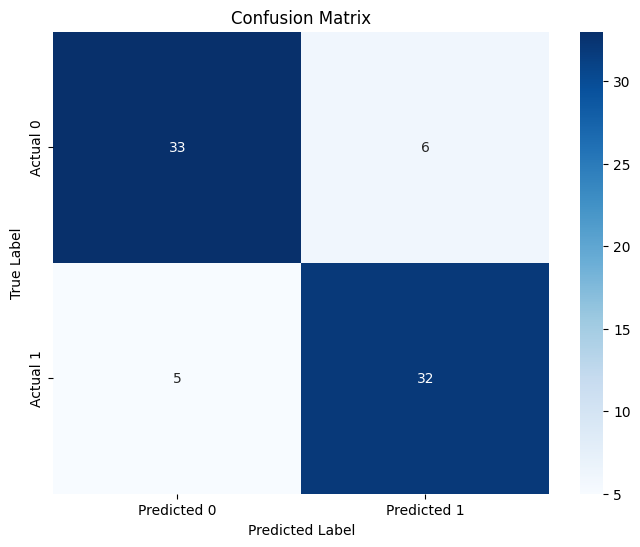

In [77]:
cm = confusion_matrix(y_test, y_pred_svm_2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Decision Tree

In [78]:
from sklearn.tree import DecisionTreeClassifier

# Pick 5% of the training set
train_size = int(0.05 * len(X_train_scaled_pca))
X_train_small = X_train_scaled_pca[:train_size]
y_train_small = y_train[:train_size]

# Set regularization to zero and train Decision Tree
dt = DecisionTreeClassifier(ccp_alpha=0) # ccp_alpha=0 effectively sets regularization to zero
dt.fit(X_train_small, y_train_small)

# Make predictions
y_pred = dt.predict(X_train_small)

# Calculate Mean Squared Error
mse = mean_squared_error(y_train_small, y_pred)
print(f"Mean Squared Error on the small training set: {mse}")

Mean Squared Error on the small training set: 0.0


### DT with PCA

In [80]:
from sklearn.tree import DecisionTreeClassifier
# Define the parameter grid

param_grid3 = {
                'criterion': ['gini', 'entropy'],
                'max_depth': [3, 4, 5, 6, 7],  # Wider range of values
                'min_samples_split': [5, 8, 9, 10, 11, 12, 15],
                'min_samples_leaf': [2, 3, 4, 5, 6],
                # 'max_features': ['auto', 'sqrt', 'log2']  # Added max_features
}

# Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV
grid_search3 = GridSearchCV(dt, param_grid3, cv=5, scoring='accuracy')  # 5-fold cross-validation
start = time()
grid_search3.fit(X_train_scaled_pca, y_train)
end = time()
print("search time: ", end - start)
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search3.best_params_)
print("Validation accuracy:", grid_search3.best_score_)

search time:  10.865283012390137
Best hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 3, 'min_samples_split': 10}
Validation accuracy: 0.8235748792270531


In [176]:
# use the best hyperparameter to train on whole train set
tuned_dt = DecisionTreeClassifier(criterion='gini', max_depth=4, min_samples_leaf=3, min_samples_split=10)
tuned_dt.fit(X_train_scaled_pca, y_train)

y_train_pred = tuned_dt.predict(X_train_scaled_pca)
y_pred_dt = tuned_dt.predict(X_test_scaled_pca)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_dt)}")

Training Accuracy: 0.8678414096916299
Testing Accuracy: 0.8289473684210527


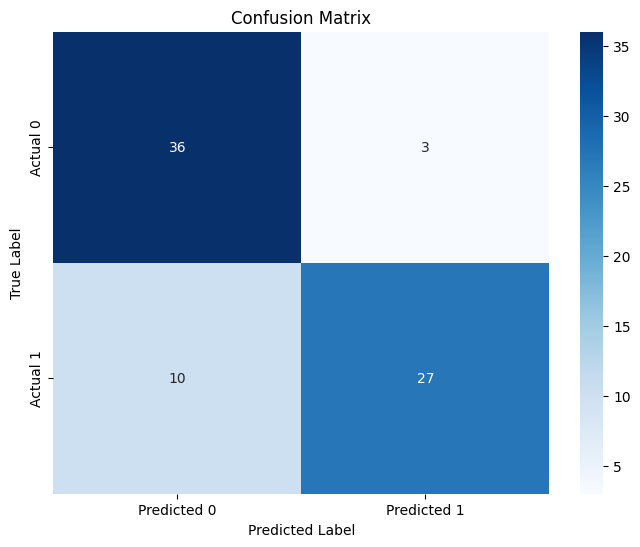

In [82]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### DT without PCA

In [189]:
param_grid3_2 = {
                'criterion': ['gini', 'entropy'],
                'max_depth': [5, 6, 7, 8, 9, 10],  # Wider range of values
                'min_samples_split': [2, 3, 4, 5, 6, 7, 8],
                'min_samples_leaf': [1, 2, 3, 4, 5],
                'splitter': ['best', 'random']
                # 'max_features': ['auto', 'sqrt', 'log2']  # Added max_features
}

# Initialize Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)

# Perform GridSearchCV
grid_search3_2 = GridSearchCV(dt, param_grid3_2, cv=5, scoring='accuracy')  # 5-fold cross-validation
start = time()
grid_search3_2.fit(X_train_scaled, y_train) # fit data without PCA
end = time()
print("search time: ", end - start)
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search3_2.best_params_)
print("Validation accuracy:", grid_search3_2.best_score_)

search time:  15.579789876937866
Best hyperparameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 2, 'splitter': 'random'}
Validation accuracy: 0.8365217391304347


In [191]:
# use the best hyperparameter to train on whole train set
tuned_dt_2 = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=3, min_samples_split=2, splitter='random', random_state=42)
tuned_dt_2.fit(X_train_scaled, y_train)

y_train_pred = tuned_dt_2.predict(X_train_scaled)
y_pred_dt_2 = tuned_dt_2.predict(X_test_scaled)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_dt_2)}")

Training Accuracy: 0.9074889867841409
Testing Accuracy: 0.7763157894736842


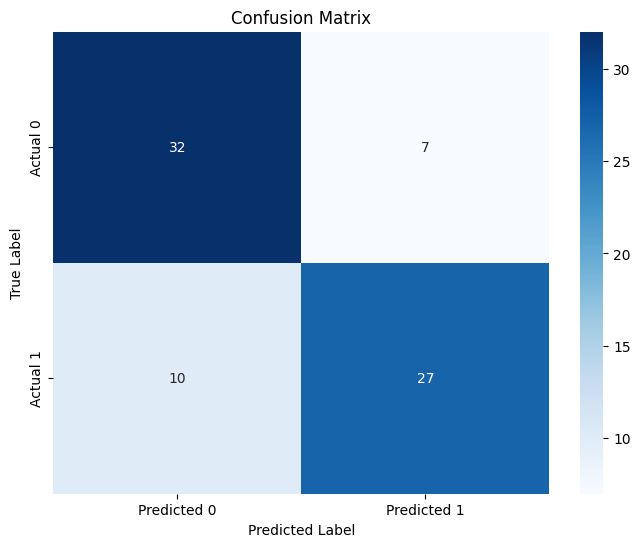

In [194]:
cm = confusion_matrix(y_test, y_pred_dt_2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Random Forest

In [196]:
from sklearn.ensemble import RandomForestClassifier

# Pick 5% of the training set
train_size = int(0.05 * len(X_train_scaled_pca))
X_train_small = X_train_scaled_pca[:train_size]
y_train_small = y_train[:train_size]

# Set regularization to zero and train Random Forest
rf = RandomForestClassifier(ccp_alpha=0, random_state=42)  # ccp_alpha=0 effectively sets regularization to zero
rf.fit(X_train_small, y_train_small)

# Make predictions
y_pred = rf.predict(X_train_small)

# Calculate Mean Squared Error
mse = mean_squared_error(y_train_small, y_pred)
print(f"Mean Squared Error on the small training set: {mse}")

Mean Squared Error on the small training set: 0.0


### RF with PCA

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest
param_grid4 = {
    'n_estimators': [200, 220,240],  # Number of trees in the forest [50,100,200] - [100,200,220] -
    'max_depth': [None, 10],  # Maximum depth of each tree
    'min_samples_split': [10, 12, 14, 16],  # Minimum samples required to split an internal node [2, 3, 4, 5, 10] -
    'min_samples_leaf': [4, 5, 6, 7]  # Minimum samples required to be at a leaf node
}

# Initialize Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Perform GridSearchCV
grid_search4 = GridSearchCV(rf, param_grid4, cv=5, scoring='accuracy')
start = time()
grid_search4.fit(X_train_scaled_pca, y_train)
end = time()
print("search time: ", end - start)
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search4.best_params_)
print("Validation accuracy:", grid_search4.best_score_)

# # Evaluate the best model on the test set
# best_rf = grid_search4.best_estimator_
# y_pred_rf = best_rf.predict(X_test_scaled_pca)

# # Print classification report and confusion matrix
# print(classification_report(y_test, y_pred_rf))
# print(confusion_matrix(y_test, y_pred_rf))

# training_accuracy = best_rf.score(X_train_scaled_pca, y_train)
# print(f"Training Accuracy: {training_accuracy}")
# #accuracy_score(y_test, y_pred_rf)
# print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_rf)}")


search time:  196.81922554969788
Best hyperparameters: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 12, 'n_estimators': 220}
Validation accuracy: 0.8456038647342995


In [ ]:
# use the best hyperparameter to train on whole train set
tuned_rf = RandomForestClassifier(n_estimators=220, min_samples_split=12, min_samples_leaf=5, max_depth=None, random_state=42)
tuned_rf.fit(X_train_scaled_pca, y_train)

y_train_pred = tuned_rf.predict(X_train_scaled_pca)
y_pred_rf = tuned_rf.predict(X_test_scaled_pca)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_rf)}")

Training Accuracy: 0.8810572687224669
Testing Accuracy: 0.8289473684210527


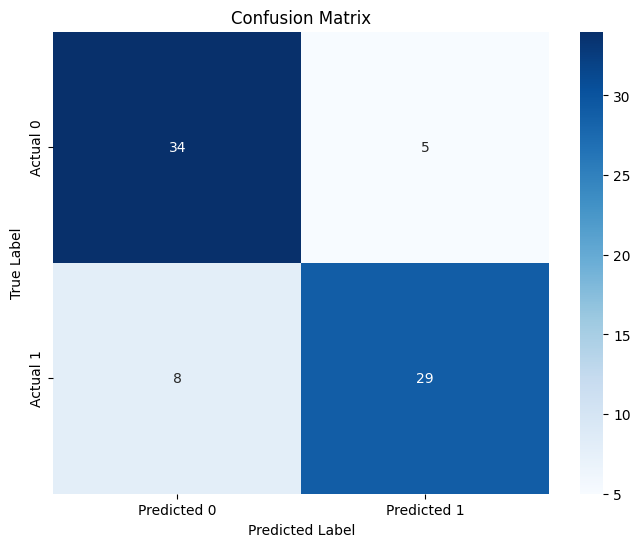

In [ ]:

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### RF without PCA

In [226]:
# Define the parameter grid for Random Forest
param_grid4_2 = {
    'n_estimators': [220,240,260],  # Number of trees in the forest
    # 'max_depth': [None, 10],  # Maximum depth of each tree
    # 'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': [3,5,10,20],
    'min_samples_leaf': [4, 6, 8,10,12]
}

# Initialize Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Perform GridSearchCV
grid_search4_2 = GridSearchCV(rf, param_grid4_2, cv=5, scoring='accuracy')
start = time()
grid_search4_2.fit(X_train_scaled, y_train)
end = time()
print("search time: ", end - start)
# Print the best hyperparameters and accuracy
print("Best hyperparameters:", grid_search4_2.best_params_)
print("Validation accuracy:", grid_search4_2.best_score_)

search time:  122.95883584022522
Best hyperparameters: {'min_samples_leaf': 8, 'min_samples_split': 3, 'n_estimators': 240}
Validation accuracy: 0.8369082125603866


In [229]:
# use the best hyperparameter to train on whole train set
tuned_rf_2 = RandomForestClassifier(criterion='gini', n_estimators=240, min_samples_leaf=8, min_samples_split=3, max_depth=None, random_state=42)
tuned_rf_2.fit(X_train_scaled, y_train)

y_train_pred = tuned_rf_2.predict(X_train_scaled)
y_pred_rf_2 = tuned_rf_2.predict(X_test_scaled)
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test, y_pred_rf_2)}")

Training Accuracy: 0.8678414096916299
Testing Accuracy: 0.868421052631579


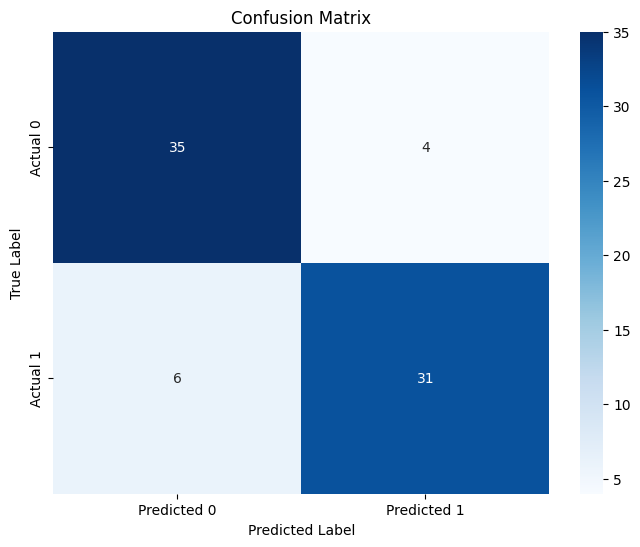

In [223]:
cm = confusion_matrix(y_test, y_pred_rf_2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Neural Network (tensorflow)

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models, regularizers
from tensorflow.keras.utils import to_categorical


In [ ]:
# one hot encoding for labels
def to_one_hot(Y):
    n_col = np.amax(Y) + 1
    binarized = np.zeros((len(Y), n_col))
    for i in range(len(Y)):
        binarized[i, Y[i]] = 1.
    return binarized

In [ ]:
# X_train_np = X_train_scaled_pca
y_train_np = np.array(y_train)
# X_test_np = X_test_scaled_pca
y_test_np = np.array(y_test)

In [ ]:
y_train_one_hot = to_one_hot(y_train_np)
y_test_one_hot = to_one_hot(y_test_np)

In [ ]:
# Pick 5% of the training set
train_size = int(0.05 * len(X_train_scaled_pca))
X_train_small = X_train_scaled_pca[:train_size]
y_train_small = y_train_one_hot[:train_size] # Use one-hot encoded labels

# Set regularization to zero and create the model
model_relu_adam_softmax = keras.Sequential([
    layers.Dense(10, activation='relu', input_shape=(X_train_small.shape[1],), kernel_regularizer=None), # L2 regularization set to zero
    layers.Dense(2, activation='softmax', kernel_regularizer=None) #L2 regularization set to zero
])

# Compile the model with Mean Squared Error loss
model_relu_adam_softmax.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# Train the model
model_relu_adam_softmax.fit(X_train_small, y_train_small, epochs=500, verbose=0) # Adjust epochs and batch_size as needed

# Evaluate the model and print the loss
loss, accuracy = model_relu_adam_softmax.evaluate(X_train_small, y_train_small, verbose=0)
print(f"Mean Squared Error on the small training set: {loss}")
print(f"Training Accuracy: {accuracy}")

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mean Squared Error on the small training set: 0.02169063314795494
Training Accuracy: 1.0


In [ ]:
# import tensorflow as tf
def create_model(neurons1=10, learning_rate=0.01, drop=0.3, alpha=0.001):
# def create_model(neurons1=10, neurons2=10, learning_rate=0.01, drop=0.3, alpha=0.001):
    model = tf.keras.models.Sequential([
        layers.Input(shape=(6,)),
        layers.Dense(neurons1, activation='relu', kernel_regularizer=regularizers.l2(alpha)),
        layers.Dropout(drop),
        layers.Dense(2, activation='sigmoid')
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model

param_grid5 = {
    'model__neurons1': [10, 15, 20],  # Prefix with 'model__'
    'model__drop': [0.2, 0.3, 0.5],  # Prefix with 'model__'
    'model__learning_rate': [0.001, 0.01, 0.1],  # Prefix with 'model__'
    'model__alpha': [0.001, 0.01, 0.1]  # Prefix with 'model__'
}

In [ ]:
!pip install scikeras

In [ ]:
from scikeras.wrappers import KerasClassifier
from time import time
# from sklearn.model_selection import GridSearchCV
model = KerasClassifier(model=create_model, verbose=0)

grid_search5 = GridSearchCV(estimator=model, param_grid=param_grid5, cv=5, scoring='accuracy')

start = time()
grid_search5.fit(X_train_scaled_pca, y_train_one_hot, epochs = 500)
end = time()
print("search time: ", end - start)

search time:  11113.795913934708


In [ ]:
print("Best hyperparameters:", grid_search5.best_params_)
print("Validation accuracy:", grid_search5.best_score_)

Best hyperparameters: {'model__alpha': 0.01, 'model__drop': 0.2, 'model__learning_rate': 0.01, 'model__neurons1': 15}
Validation accuracy: 0.8502415458937198


In [ ]:
tuned_nn = create_model(neurons1=15, learning_rate=0.01, drop=0.2, alpha=0.01)
tuned_nn.fit(X_train_scaled_pca, y_train_one_hot, epochs=500)

y_train_pred = tuned_nn.predict(X_train_scaled_pca)
y_pred_nn = tuned_nn.predict(X_test_scaled_pca)


Epoch 1/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6914 - loss: 0.7392
Epoch 2/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7074 - loss: 0.6694  
Epoch 3/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7165 - loss: 0.6191 
Epoch 4/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7515 - loss: 0.5873 
Epoch 5/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7932 - loss: 0.5619 
Epoch 6/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8151 - loss: 0.5166  
Epoch 7/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7971 - loss: 0.5268 
Epoch 8/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8372 - loss: 0.4575 
Epoch 9/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8265 - loss: 0.4421 
Epoch 10/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8055 - loss: 0.4340 
Epoch 11/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8154 - loss: 0.4946 
Epoch 12/500
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8325 - lo

Training Accuracy: 0.8370044052863436
Testing Accuracy: 0.8026315789473685


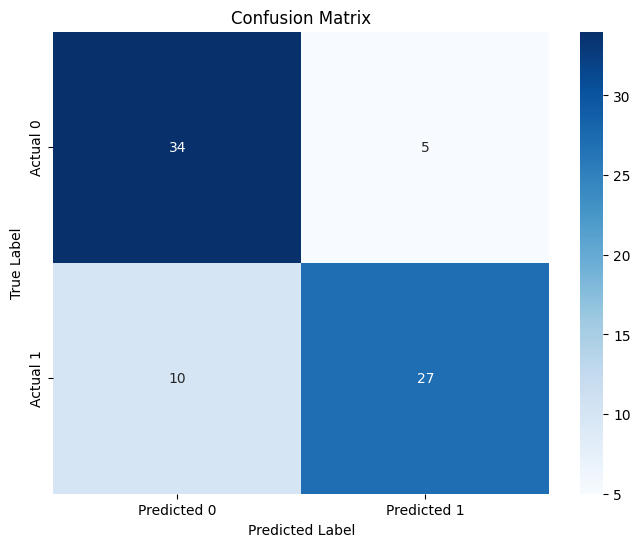

In [ ]:
y_train_pred = (y_train_pred > 0.5)
y_pred_nn = (y_pred_nn > 0.5)

print(f"Training Accuracy: {accuracy_score(y_train_one_hot, y_train_pred)}")
print(f"Testing Accuracy: {accuracy_score(y_test_one_hot, y_pred_nn)}")

cm = confusion_matrix(y_test_one_hot.argmax(axis=1), y_pred_nn.argmax(axis=1))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()